# Percepční mapování mobilních operátorů pomocí PROC MDS

## Shrnutí

Tým telekomunikačního marketingového výzkumu měří, jak podobně zákazníci vnímají osm konkurenčních mobilních operátorů, a pomocí **PROC MDS** rekonstruuje dvourozměrnou percepční mapu z matice odlišnosti. Dvě latentní osy - kvalita sítě a cena/hodnota - jsou záměrně navrženy tak, aby se měnily *nezávisle*, takže získaná mapa je skutečně dvourozměrná: ukazuje, které značky jsou vnímány jako substituty, které zaujímají odlišné pozicování a jak dobře dvě dimenze shrnují konkurenční prostředí.

## Zdroje dat

| Datová sada | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (jeden na operátora) | `Carrier` (ID), `D1`-`D8` | Čtvercová symetrická matice vnímané odlišnosti mezi 8 mobilními operátory na škále 0-10 (0 = vnímáno jako identické, vyšší = odlišnější). Generována z latentních 2D pozic značek na dvou *nezávislých* osách (kvalita sítě a cena/hodnota) plus šum z průzkumu pomocí `rand('NORMAL')`. Diagonála je 0. |

# Percepční mapování mobilních operátorů pomocí PROC MDS

Týmy marketingového výzkumu v telekomunikacích běžně žádají výzkumné panely, aby ohodnotily, jak *podobní* nebo *odlišní* si konkurenční operátoři připadají. Tato párová hodnocení tvoří **matici blízkosti**, která nemá přirozený souřadnicový systém - ale **vícerozměrné škálování (MDS)** dokáže rekonstruovat nízkorozměrnou mapu, ve které vzdálenost mezi dvěma značkami reprodukuje jejich vnímanou odlišnost.

V tomto sešitu:

1. Syntetizujeme realistickou matici odlišnosti pro 8 operátorů ze dvou *nezávislých* pozicovacích os (kvalita sítě a cena/hodnota).
2. Proložíme dvourozměrný metrický MDS model pomocí `PROC MDS`.
3. Vyčteme získané souřadnice a míru neshody (badness-of-fit), poté vykreslíme percepční mapu z získaných souřadnic, abychom posoudili, jak dobře dvě dimenze vysvětlují konkurenční prostředí.

## Krok 1 - Sestavení syntetické matice odlišnosti

Umístíme každého operátora na *skutečnou* latentní pozici na dvou **nezávislých** osách:

- **Osa kvality sítě** - prémiový celostátní operátoři skórují vysoko; rozpočtoví virtuální operátoři (MVNO) skórují nízko.
- **Osa cena/hodnota** - hodnotové/předplacené značky skórují vysoko; prémiově ceněné značky skórují nízko.

Zásadní je, že obě osy jsou napříč osmi značkami nekorelované: vysoce kvalitní operátor může být buď prémiově ceněný (NorthStar), nebo agresivně cenově zvýhodněný (BluePeak), a rozpočtově kvalitní operátor může být na ose ceny kdekoli. Právě tato nezávislost způsobuje, že získaná mapa je skutečně dvourozměrná, místo aby se zhroutila na jedinou přímku.

Vnímaná odlišnost mezi dvěma operátory je euklidovská vzdálenost mezi jejich latentními pozicemi, přeškálovaná na průzkumovou škálu 0-10 a narušená symetrickým šumem z průzkumu. `PROC MDS` očekává **čtvercovou matici**: jedno pozorování na objekt a jeden číselný sloupec na objekt, přičemž pořadí řádků odpovídá pořadí sloupců. Zapíšeme sloupce `D1`-`D8` plus štítek `Carrier` a vynutíme, aby matice byla symetrická s nulovou diagonálou.

In [1]:
data carrier_dissim;
    DÉLKA Carrier $ 12;
    CALL streaminit(20240517);

    /* Skutecne 2D latentni pozice na dvou NEZAVISLYCH osach:
       qx = kvalita site, px = cena/hodnota (korelace ~ 0). */
    POLE qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    POLE px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    POLE nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Symetricka sumova matice, vygenerovana jednou, nulova diagonala */
    POLE e[8,8] _temporary_;
    OPAKUJ i = 1 TO 8;
        e[i,i] = 0;
        OPAKUJ j = i+1 TO 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        KONEC;
    KONEC;

    POLE d[8] D1-D8;
    OPAKUJ i = 1 TO 8;
        Carrier = nm[i];
        OPAKUJ j = 1 TO 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* preskalovani latentni vzdalenosti na pruzkumovou skalu 0-10 */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        KONEC;
        d[i] = 0;            /* znacka je totozna sama se sebou */
        VÝSTUP;
    KONEC;

    PONECHAT Carrier D1-D8;
SPUSTIT;

PROCEDURA TISK data=carrier_dissim noobs ŠTÍTEK;
    ŠTÍTEK Carrier = 'Operátor';
    NÁZEV 'Matice vnímané odlišnosti (0 = identické, 10 = nejvíce odlišné)';
SPUSTIT;

                            Matice vnímané odlišnosti (0 = identické, 10 = nejvíce odlišné)                             

    Operátor   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Krok 2 - Proložení dvourozměrného metrického MDS modelu

Odlišnosti modelujeme na úrovni `LEVEL=INTERVAL` (metrické MDS, které umožňuje aditivní konstantu), v `DIM=2`, aby výsledek šel vykreslit na plochou mapu. Data jsou odlišnosti (výchozí nastavení), uložené jako plná `SQUARE` matice.

Klíčové příkazy a volby:

- `VAR D1-D8` vyjmenovává osm sloupců, jeden na objekt.
- `ID Carrier` připojí názvy značek, aby se objevily ve výstupu a v souřadnicích `OUT=`.
- `OUT=` zachytí souřadnice objektů (požadováno pomocí `OCONFIG`) a `OUTFIT=` zachytí souhrn míry neshody.
- `PCONFIG`, `PFIT` a `PFINAL` vytisknou souřadnice, statistiky shody a finální odhady parametrů.

Percepční mapu vykreslíme sami v Kroku 3 ze získaných souřadnic `OUT=`, což dává plnou kontrolu nad štítky značek a škálováním os.

In [2]:
PROCEDURA mds data=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    PROMĚNNÁ D1-D8;
    id Carrier;
    NÁZEV 'Dvourozměrné MDS vnímání mobilních operátorů';
SPUSTIT;

                            Matice vnímané odlišnosti (0 = identické, 10 = nejvíce odlišné)                             




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/0000812b-ab7a-4c80-878d-2ac01d13d5f1/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.78 seconds
  cpu   1.78 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/0000812b-ab7a-4c80-878d-2ac01d13d5f1/mds_fit.avro (2 rows, 3 columns).


## Krok 3 - Získání rekonstruovaných souřadnic a vykreslení mapy

S `OCONFIG` nese datová sada `OUT=` odhadované souřadnice objektů (jeden řádek na operátora, jeden sloupec na dimenzi). Vytiskneme tyto souřadnice a míru neshody, poté vykreslíme `DIM2` proti `DIM1` pomocí `PROC SGPLOT` - každý bod označíme názvem operátora - abychom vykreslili percepční mapu.

Souřadnice MDS jsou určeny pouze až na rotaci, zrcadlení a jednotné škálování, takže absolutní znaménka os jsou libovolná; důležitá je *relativní* geometrie značek. Po rotaci jedna osa sleduje kvalitu sítě a druhá cenu/hodnotu.

                                      Získaná MDS konfigurace (souřadnice objektů)                                      

  Obs  _TYPE_      Operátor      Dimenze 1      Dimenze 2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                        Souhrn míry neshody (badness-of-fit) MDS                                        

  Obs    Počet dimenzí   Matice   Kritérium neshody
    1                2                 1.8502928101
    2                2  MATRIX1        1.8502928101

                                        Souhrn míry neshody (badness-of-fit)


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


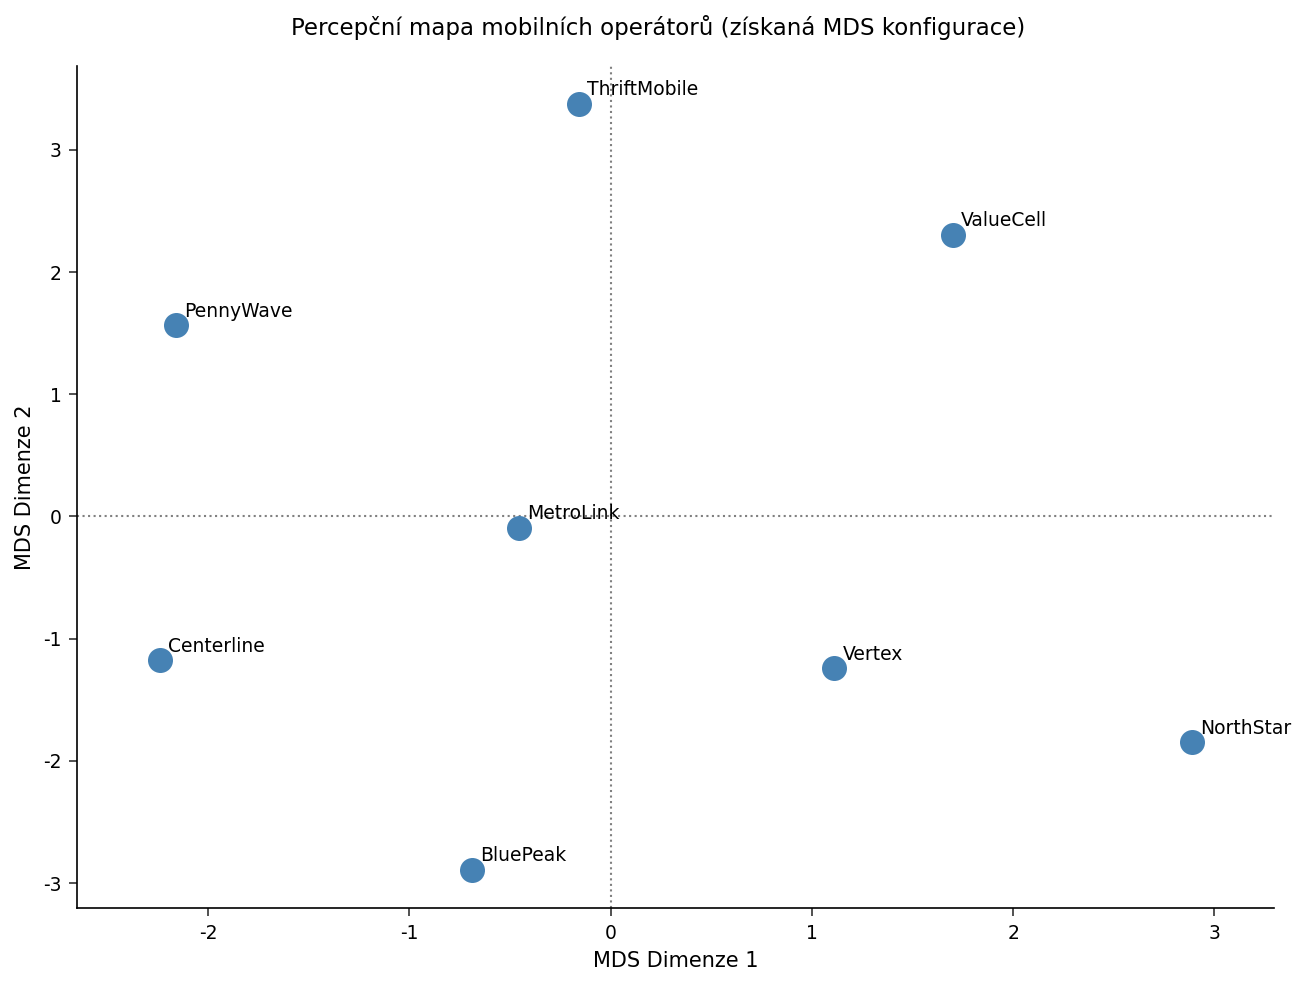

In [3]:
PROCEDURA TISK data=mds_out ŠTÍTEK;
    ŠTÍTEK _name_='Operátor' DIM1='Dimenze 1' DIM2='Dimenze 2';
    NÁZEV 'Získaná MDS konfigurace (souřadnice objektů)';
SPUSTIT;

PROCEDURA TISK data=mds_fit ŠTÍTEK;
    ŠTÍTEK _dimens_='Počet dimenzí' _matrix_='Matice' criter='Kritérium neshody';
    NÁZEV 'Souhrn míry neshody (badness-of-fit) MDS';
SPUSTIT;

/* Ponechame konfiguracni radky a dame znacce jednoduse pojmenovany
   sloupec, aby ho SGPLOT mohl vytisknout vedle kazdeho bodu. */
data mds_config;
    NASTAVIT mds_out;
    KDE _TYPE_ = 'CONFIG';
    DÉLKA Brand $ 12;
    Brand = _NAME_;
    PONECHAT Brand DIM1 DIM2;
SPUSTIT;

/* Vykresleni percepcni mapy ze ziskanych souradnic, kazdy bod
   oznacime nazvem operatora. */
PROCEDURA SGPLOT data=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS ŠTÍTEK='MDS Dimenze 1';
    YAXIS ŠTÍTEK='MDS Dimenze 2';
    NÁZEV 'Percepční mapa mobilních operátorů (získaná MDS konfigurace)';
SPUSTIT;

## Krok 4 — Seřazení vnímaných substitutů

Praktickým výstupem pro brand tým je pro každého operátora zjistit konkurenta, který je vnímán jako *nejpodobnější* (nejmenší mimodiagonální odlišnost). Přetvoříme matici do dlouhého formátu a vybereme nejbližšího souseda pro každého operátora - tyto dvojice jsou nejbližší substituty a nejostřejší konkurenční hrozby.

In [4]:
data dissim_long;
    NASTAVIT carrier_dissim;
    DÉLKA Other $ 12;
    POLE d[8] D1-D8;
    POLE nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    OPAKUJ j = 1 TO 8;
        Other = nm[j];
        Dissimilarity = d[j];
        KDYŽ Carrier ne Other PAK VÝSTUP;
    KONEC;
    PONECHAT Carrier Other Dissimilarity;
SPUSTIT;

PROCEDURA ŘADIT data=dissim_long;
    PODLE Carrier Dissimilarity;
SPUSTIT;

data nearest;
    NASTAVIT dissim_long;
    PODLE Carrier Dissimilarity;
    KDYŽ first.Carrier;
SPUSTIT;

PROCEDURA TISK data=nearest noobs ŠTÍTEK;
    ŠTÍTEK Other = 'Nejbližší vnímaný substitut'
          Dissimilarity = 'Odlišnost';
    NÁZEV 'Každý operátor a jeho nejbližší vnímaný substitut';
SPUSTIT;

                                   Každý operátor a jeho nejbližší vnímaný substitut                                    

     Carrier       Nejbližší vnímaný substitut   Odlišnost
BluePeak      Centerline                                 2
Centerline    MetroLink                                1.9
MetroLink     Vertex                                   1.7
NorthStar     Vertex                                   1.6
PennyWave     MetroLink                                  2
ThriftMobile  ValueCell                                1.8
ValueCell     ThriftMobile                             1.8
Vertex        NorthStar                                1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretace výsledků

Protože jsme odlišnosti vygenerovali ze skutečné dvourozměrné latentní struktury (kvalita sítě a cena/hodnota, navržené tak, aby se měnily nezávisle) plus mírného šumu z průzkumu, `PROC MDS` rekonstruuje čistou dvourozměrnou konfiguraci. Kritérium míry neshody se ustálí kolem 1,85 - těsná shoda, která potvrzuje, že dvě dimenze vysvětlují téměř celou vnímanou strukturu.

Při čtení získané mapy (osy jsou určeny pouze až na rotaci, zrcadlení a měřítko, takže interpretujeme směry, nikoli absolutní znaménka):

- **Jedna osa sleduje kvalitu sítě** - odděluje prémiové celostátní značky (NorthStar, Vertex, BluePeak) od rozpočtových MVNO (ThriftMobile, PennyWave, ValueCell), přičemž MetroLink a Centerline sedí uprostřed.
- **Druhá osa sleduje cenu/hodnotu** - odděluje agresivně cenově zvýhodněné pozicování od prémiově ceněného pozicování, což vysvětluje, proč vysoce kvalitní značka jako BluePeak leží daleko od stejně vysoce kvalitního NorthStar: sdílejí reputaci sítě, ale soutěží s velmi odlišnými cenovými příběhy.
- Mapa neukazuje jediný dominantní gradient: značky se rozprostírají do všech čtyř kvadrantů, takže konkurenční prostředí je skutečně dvourozměrné, nikoli jedinou přímkou od prémiového k rozpočtovému.

**Tabulka nejbližších substitutů** promění mapu v akční seznam. Nejbližší vnímaný rival každého operátora je značka sedící vedle něj na mapě - NorthStar a Vertex kotví prémiový roh, ValueCell a ThriftMobile tvoří pár v hodnotovém rohu, a MetroLink vychází jako nejbližší substitut pro několik značek středního trhu, protože zaujímá střed mapy. Těsné dvojice signalizují přímé rivaly; prázdné oblasti mezi shluky zvýrazňují neobsazené pozicování, na které by mohla mířit vyzyvatelská značka.